# Notebook v2 — Prédiction de `business_domain`
## Exploitation optimisée des colonnes texte

### Changements clés vs. v1
| Colonne | Avant (v1) | Maintenant (v2) |
|---|---|---|
| `column_names_text` | TF-IDF word mélangé avec les autres | **TF-IDF dédié** — signal primaire du modèle |
| `column_type_signature_text` | TF-IDF word → `varchar2`/`number` = top features = bruit | **Supprimé du TF-IDF** — types SQL = bruit pur, noms dupliqués |
| `column_value_semantics_text` | TF-IDF word → `label`/`identifier` = top features = bruit | **36 features numériques** (comptage de chaque annotation sémantique) |
| `column_sample_values_text` | TF-IDF word (99.9% vide) | **Supprimé** |
| `column_observed_pattern_text` | TF-IDF word (99.9% vide) | **Supprimé** |

### Pourquoi ça change tout
- `column_names_text` contient les noms de colonnes métier (`EMPLID`, `VENDOR_ID`, `GL_ACCOUNT`) — c'est le **vrai signal sémantique**
- Les types SQL (`varchar2`, `number`, `date`) sont identiques partout → bruit
- Les 36 labels sémantiques (`financial_amount`, `person_identifier`) sont informatifs comme **profil structuré**, pas comme tokens TF-IDF


## 1. Setup

In [5]:
import importlib, subprocess, sys
REQUIRED = ["lightgbm", "joblib", "scipy", "scikit-learn", "pandas", "numpy", "matplotlib"]
for pkg in REQUIRED:
    name = pkg.replace("-", "_")
    try:
        importlib.import_module(name if name != "scikit_learn" else "sklearn")
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
print("Dépendances prêtes.")


Dépendances prêtes.


In [6]:
import os, re, json, time, warnings
from pathlib import Path
from contextlib import contextmanager
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import hstack, csr_matrix
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from lightgbm import LGBMClassifier
import joblib

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)

@contextmanager
def timer(label):
    t0 = time.perf_counter()
    yield
    print(f"[{label}] {time.perf_counter()-t0:.2f}s")


## 2. Configuration

In [7]:
RANDOM_STATE = 42
TEST_SIZE = 0.20
N_FOLDS = 5
TARGET = "business_domain"

DATA_FILENAME = r"C:\Users\Salem\Desktop\Projets\pfe\Projet\exports\dataset_asset_ml_run_5_for_labeling_sample_20000_enriched_business_domain_v4.csv"

# --- Qualité labels ---
MIN_CONSENSUS_FILTER = None
USE_CONSENSUS_AS_WEIGHT = True

# --- Colonnes à exclure (fuites + IDs) ---
LEAK_COLS = [
    "business_domain_raw", "business_domain_label", "labeling_notes",
    "llm_votes_json", "llm_consensus_score", "llm_models_used",
    "llm_prompt_version", "llm_status", "confidence", "reason",
]
ID_COLS = ["run_id", "asset_id"]
DROP_COLS = LEAK_COLS + ID_COLS

# --- Colonnes SUPPRIMÉES du TF-IDF (bruit technique / vides) ---
# Ces colonnes ne sont PLUS utilisées en TF-IDF.
# Elles sont soit transformées en features structurées, soit ignorées.
DROPPED_TEXT_COLS = [
    "column_type_signature_text",    # 70% bruit SQL (varchar2, number)
    "column_value_semantics_text",   # transformé en 36 features numériques
    "column_sample_values_text",     # 99.9% vide
    "column_observed_pattern_text",  # 99.9% vide
]

# --- Features texte pour TF-IDF ---
# Seules les colonnes contenant du VRAI vocabulaire métier
TEXT_COLS_CHAR = ["technical_name", "source_ref"]
TEXT_COLS_WORD = ["column_names_text"]   # LE signal principal

NUM_COLS = [
    "field_count", "nullable_field_count", "non_nullable_field_count",
    "numeric_field_count", "date_field_count", "text_field_count",
    "large_text_field_count", "avg_data_length", "max_data_length",
    "row_count", "size_bytes", "size_mb",
]
CAT_COLS = ["source_system", "asset_type", "has_profile_data"]

# --- Paramètres TF-IDF ---
CHAR_MAX_FEATURES = 50_000
WORD_MAX_FEATURES = 80_000
CHAR_NGRAMS = (3, 5)
WORD_NGRAMS = (1, 2)

# --- Stopwords SQL/PeopleSoft à exclure du TF-IDF ---
SQL_STOPWORDS = [
    "varchar2", "number", "date", "timestamp", "clob", "blob", "long",
    "char", "raw", "xmltype", "float", "integer", "nvarchar2", "nclob",
    "timestamp(6)", "sysadm", "ps",
]

# --- Les 36 labels sémantiques connus → features numériques ---
KNOWN_SEMANTIC_LABELS = [
    "label", "quantity", "identifier", "financial_amount", "classification",
    "date_or_timestamp", "processing_identifier", "status",
    "reference_identifier", "percentage_or_rate", "user_identifier",
    "technical_timestamp", "flag", "date_part", "comment_text",
    "person_identifier", "job_label", "postal_location", "email_address",
    "phone_number", "url", "score", "duration", "technical_identifier",
    "person_full_name", "person_first_name", "person_last_name",
    "file_reference", "other", "geo_longitude", "geo_latitude",
]

RUN_LOGREG = True
RUN_LINSVC = True
RUN_LIGHTGBM = True
RUN_CV = True

print("Config chargée.")


Config chargée.


## 3. Chargement et audit

In [8]:
def resolve_data_path(filename):
    for p in [Path(filename), Path.cwd()/filename, Path("/mnt/data")/filename,
              Path("/content")/filename, Path("/mnt/user-data/uploads")/filename]:
        if p.exists(): return p
    raise FileNotFoundError(f"CSV introuvable : {filename}")

DATA_PATH = resolve_data_path(DATA_FILENAME)
print("DATA_PATH =", DATA_PATH)

dtype_hint = {
    "source_system":"category", "asset_type":"category", "has_profile_data":"boolean",
    "field_count":"int32", "nullable_field_count":"int32",
    "non_nullable_field_count":"int32", "numeric_field_count":"int32",
    "date_field_count":"int32", "text_field_count":"int32",
    "large_text_field_count":"int32", "max_data_length":"int32",
    "avg_data_length":"float32", "row_count":"float32",
    "size_bytes":"float64", "size_mb":"float32", "llm_consensus_score":"float32",
}
with timer("read_csv"):
    df_raw = pd.read_csv(DATA_PATH, dtype=dtype_hint, low_memory=False)

print("Shape :", df_raw.shape)
print("Memory (MB) :", round(df_raw.memory_usage(deep=True).sum()/1e6, 1))


DATA_PATH = C:\Users\Salem\Desktop\Projets\pfe\Projet\exports\dataset_asset_ml_run_5_for_labeling_sample_20000_enriched_business_domain_v4.csv
[read_csv] 0.51s
Shape : (20000, 33)
Memory (MB) : 50.7


=== Distribution business_domain ===
business_domain
Finance & Contrôle                        7509
IT & Sécurité                             5303
Other                                     2321
Achats & Fournisseurs                     2165
Supply Chain / Logistique / Production    1502
RH                                         855
Ventes & Clients                           345
Name: count, dtype: int64

Ratio déséquilibre max/min : 21.8x

=== Lignes à faible consensus (< 0.8) ===
Total : 1527 (7.6%)

=== Pourquoi column_type_signature_text est du bruit ===
  'varchar2' apparaît dans 19809/20000 lignes (99%)
  'number' apparaît dans 15144/20000 lignes (76%)
  'date' apparaît dans 8898/20000 lignes (44%)
  'clob' apparaît dans 1528/20000 lignes (8%)

=== Pourquoi column_sample/observed sont inutiles ===
  column_sample_values_text: 27/20000 non-vides (0.1%)
  column_observed_pattern_text: 27/20000 non-vides (0.1%)


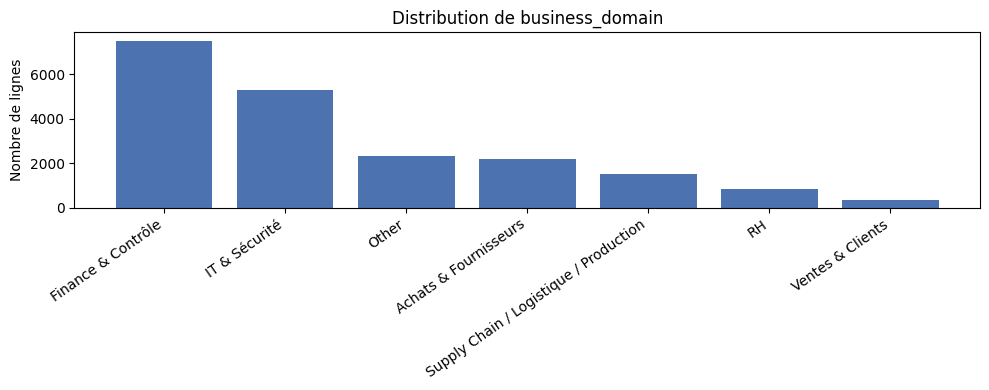

In [9]:
# --- Audit ---
print("=== Distribution business_domain ===")
target_counts = df_raw[TARGET].value_counts(dropna=False)
print(target_counts)
print(f"\nRatio déséquilibre max/min : {target_counts.max()/target_counts.min():.1f}x")

print("\n=== Lignes à faible consensus (< 0.8) ===")
low = df_raw[df_raw["llm_consensus_score"] < 0.8]
print(f"Total : {len(low)} ({100*len(low)/len(df_raw):.1f}%)")

# Démonstration du bruit dans les anciennes features
print("\n=== Pourquoi column_type_signature_text est du bruit ===")
types_text = df_raw["column_type_signature_text"].fillna("").astype(str).str.lower()
for word in ["varchar2", "number", "date", "clob"]:
    print(f"  '{word}' apparaît dans {types_text.str.contains(word).sum()}/{len(df_raw)} lignes"
          f" ({100*types_text.str.contains(word).mean():.0f}%)")

print("\n=== Pourquoi column_sample/observed sont inutiles ===")
for c in ["column_sample_values_text", "column_observed_pattern_text"]:
    non_empty = (df_raw[c].fillna("").astype(str).str.strip() != "").sum()
    print(f"  {c}: {non_empty}/{len(df_raw)} non-vides ({100*non_empty/len(df_raw):.1f}%)")

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(target_counts.index.astype(str), target_counts.values, color="#4C72B0")
ax.set_xticklabels(target_counts.index.astype(str), rotation=35, ha="right")
ax.set_title("Distribution de business_domain")
ax.set_ylabel("Nombre de lignes")
plt.tight_layout()
plt.show()


## 4. Qualité des labels — gate

In [10]:
def apply_label_quality_gate(df):
    n0 = len(df)
    if MIN_CONSENSUS_FILTER is not None and "llm_consensus_score" in df.columns:
        df = df[df["llm_consensus_score"] >= MIN_CONSENSUS_FILTER].copy()
        print(f"Filtrage consensus >= {MIN_CONSENSUS_FILTER} : {n0} -> {len(df)}")
    return df

df_gated = apply_label_quality_gate(df_raw)
print("Shape après gate :", df_gated.shape)


Shape après gate : (20000, 33)


## 5. Feature engineering — extraction sémantique structurée

### Nouvelle approche pour `column_value_semantics_text`
Au lieu de la passer en TF-IDF (où `label`/`identifier` deviennent des top features
inutiles), on extrait les **36 annotations sémantiques** comme features numériques.

Par exemple, une table RH aura un profil `{person_identifier: 3, job_label: 2, ...}`
tandis qu'une table Finance aura `{financial_amount: 8, percentage_or_rate: 3, ...}`.

C'est un signal **structuré et directement interprétable**.

In [11]:
def extract_semantic_profile(semantics_text):
    """Extrait le profil sémantique d'une ligne.
    Input:  'COL1:label | COL2:financial_amount | COL3:label'
    Output: Counter({'label': 2, 'financial_amount': 1})
    """
    counts = Counter()
    if pd.isna(semantics_text) or str(semantics_text).strip() == "":
        return counts
    for pair in str(semantics_text).split("|"):
        pair = pair.strip()
        if ":" in pair:
            _, label = pair.split(":", 1)
            label = label.strip().lower()
            counts[label] += 1
    return counts

def build_semantic_features(df):
    """Crée les features sémantiques à partir de column_value_semantics_text.
    Retourne un DataFrame avec une colonne par label sémantique connu."""
    profiles = df["column_value_semantics_text"].apply(extract_semantic_profile)

    sem_df = pd.DataFrame(index=df.index)
    for label in KNOWN_SEMANTIC_LABELS:
        sem_df[f"sem_{label}"] = profiles.apply(lambda c: c.get(label, 0)).astype(np.int16)

    # Ratios sémantiques (normalisés par le nombre total de colonnes)
    total = sem_df.sum(axis=1).replace(0, 1).astype(np.float32)
    for label in ["financial_amount", "person_identifier", "user_identifier",
                  "quantity", "processing_identifier", "flag", "status"]:
        col = f"sem_{label}"
        if col in sem_df.columns:
            sem_df[f"ratio_{label}"] = (sem_df[col] / total).astype(np.float32)

    return sem_df

# Test rapide
_test = build_semantic_features(df_gated.head(5))
print("Semantic features shape:", _test.shape)
print("Colonnes:", list(_test.columns[:10]), "...")
print(_test.head(3))


Semantic features shape: (5, 38)
Colonnes: ['sem_label', 'sem_quantity', 'sem_identifier', 'sem_financial_amount', 'sem_classification', 'sem_date_or_timestamp', 'sem_processing_identifier', 'sem_status', 'sem_reference_identifier', 'sem_percentage_or_rate'] ...
   sem_label  sem_quantity  sem_identifier  sem_financial_amount  \
0          1             0               0                     0   
1          9             0               0                     0   
2         18             2               0                     0   

   sem_classification  sem_date_or_timestamp  sem_processing_identifier  \
0                   1                      0                          0   
1                   0                      1                          0   
2                   8                      7                          0   

   sem_status  sem_reference_identifier  sem_percentage_or_rate  \
0           0                         0                       0   
1           0                

In [12]:
# --- Lexiques métier ---
DOMAIN_KEYWORDS = {
    "finance": [
        "invoice", "payment", "ledger", "gl", "tax", "budget", "amount",
        "cost", "expense", "revenue", "accounting", "journal", "account",
        "ap", "ar", "fi", "glacct", "treasur", "asset", "deprec",
        "facture", "paiement", "comptabil", "compte", "montant", "devise",
        "currency", "vat", "tva",
    ],
    "hr": [
        "employee", "empl", "emplid", "job", "manager", "payroll", "absence",
        "position", "hire", "worker", "salary", "person", "headcount",
        "compensation", "benefit", "pay", "leave", "employe", "salaire",
        "poste", "conge",
    ],
    "it": [
        "user", "role", "access", "auth", "permission", "config", "server",
        "system", "login", "application", "security", "sysadm",
        "menu", "page", "xlat", "dbowner", "portal", "prcs", "audit",
    ],
    "procurement": [
        "vendor", "supplier", "purchase", "po_", "item", "stock", "inventory",
        "material", "order", "sourcing", "rfq", "contract",
        "fournisseur", "achat", "commande",
    ],
    "sales": [
        "customer", "client", "opportunity", "quote", "deal", "crm",
        "sales", "pipeline", "booking", "cust_", "cust",
        "vente", "facturation",
    ],
    "marketing": [
        "campaign", "lead", "segment", "channel", "audience", "click",
        "impression", "conversion", "promo",
    ],
    "risk": [
        "risk", "control", "incident", "compliance", "issue",
        "mitigation", "policy", "controle", "conformite",
    ],
    "supply_chain": [
        "shipment", "warehouse", "delivery", "route",
        "transport", "plant", "logistics", "bom", "prod_",
        "livraison", "entrepot", "logistique", "production",
    ],
}

PS_MODULE_PREFIXES = {
    "GL":"finance", "AP":"finance", "AR":"finance", "AM":"finance",
    "BI":"finance", "TR":"finance", "EX":"finance",
    "HR":"hr", "JOB":"hr", "PERSON":"hr", "BEN":"hr", "PAY":"hr",
    "ABS":"hr", "COMP":"hr",
    "PO":"procurement", "EP":"procurement", "RFQ":"procurement",
    "CON":"procurement", "VND":"procurement",
    "IN":"supply_chain", "PL":"supply_chain", "SF":"supply_chain",
    "MG":"supply_chain", "PROD":"supply_chain",
    "SA":"sales", "OM":"sales", "CRM":"sales",
    "PRCS":"it", "PSAUTH":"it", "PSOPR":"it", "PSROLE":"it",
    "PT":"it", "PSMENU":"it",
}

def normalize_text(x):
    if pd.isna(x): return ""
    x = str(x).lower()
    for sep in ["_", "-", "|", "/", "\\", ".", ":", ";", ",",
                "(", ")", "[", "]", "{", "}"]:
        x = x.replace(sep, " ")
    x = re.sub(r"[^a-z0-9\s]", " ", x)
    return re.sub(r"\s+", " ", x).strip()

def safe_div(a, b):
    a, b = np.asarray(a, dtype=np.float32), np.asarray(b, dtype=np.float32)
    return np.divide(a, b, out=np.zeros_like(a), where=b!=0)

def extract_prefix(tname):
    if not isinstance(tname, str): return ""
    s = tname.upper()
    s = re.sub(r"^[A-Z]+\.", "", s)
    s = re.sub(r"^PS[_]?", "", s)
    m = re.match(r"([A-Z]+)_", s)
    return m.group(1) if m else s.split("_")[0][:6]


In [13]:
def build_engineered_features(df):
    out = pd.DataFrame(index=df.index)
    fc = df["field_count"].fillna(0).astype(np.float32).values

    # Ratios structurels
    for col, name in [("numeric_field_count","ratio_numeric"),
                      ("date_field_count","ratio_date"),
                      ("text_field_count","ratio_text"),
                      ("large_text_field_count","ratio_large_text"),
                      ("nullable_field_count","ratio_nullable"),
                      ("non_nullable_field_count","ratio_non_nullable")]:
        out[name] = safe_div(df[col].fillna(0), fc)

    # Logs
    for c in ["row_count","size_bytes","size_mb","avg_data_length","max_data_length"]:
        out[f"log_{c}"] = np.log1p(df[c].fillna(0).astype(np.float32))

    out["avg_size_per_field"] = safe_div(df["size_bytes"].fillna(0), np.maximum(fc, 1))

    # Features de forme sur noms techniques
    for prefix in ["technical_name", "source_ref"]:
        s = df[prefix].fillna("").astype(str)
        out[f"{prefix}_len"] = s.str.len().astype(np.int32)
        out[f"{prefix}_token_count"] = s.str.count(r"[A-Za-z0-9]+").astype(np.int32)
        out[f"{prefix}_digit_count"] = s.str.count(r"\d").astype(np.int32)
        out[f"{prefix}_underscore_count"] = s.str.count(r"_").astype(np.int32)
        total_len = s.str.len().replace(0, 1)
        out[f"{prefix}_upper_ratio"] = (s.str.count(r"[A-Z]") / total_len).astype(np.float32)
        out[f"{prefix}_has_id"]  = s.str.contains(r"id",        case=False, regex=True).astype(np.int8)
        out[f"{prefix}_has_dt"]  = s.str.contains(r"dt|date",   case=False, regex=True).astype(np.int8)
        out[f"{prefix}_has_amt"] = s.str.contains(r"amt|amount", case=False, regex=True).astype(np.int8)
        out[f"{prefix}_has_cd"]  = s.str.contains(r"cd|code",   case=False, regex=True).astype(np.int8)

    # Préfixes PS
    if "technical_name" in df.columns:
        prefixes = df["technical_name"].apply(extract_prefix)
        for mod in sorted(set(PS_MODULE_PREFIXES.keys())):
            out[f"ps_is_{mod}"] = (prefixes == mod).astype(np.int8)

    # Keyword counts — sur column_names_text (le vrai signal métier)
    combined = (
        df["technical_name"].fillna("").astype(str) + " " +
        df["source_ref"].fillna("").astype(str) + " " +
        df["column_names_text"].fillna("").astype(str)
    ).str.lower()

    for domain, keywords in DOMAIN_KEYWORDS.items():
        pattern = r"\b(" + "|".join(re.escape(k) for k in keywords) + r")\b"
        c = combined.str.count(pattern).astype(np.int16)
        out[f"{domain}_keyword_count"] = c
        out[f"has_{domain}_keyword"] = (c > 0).astype(np.int8)

    return out.fillna(0)

def prepare_dataframe(df):
    df = df.copy()
    for col in TEXT_COLS_CHAR + TEXT_COLS_WORD:
        if col in df.columns:
            df[col] = df[col].apply(normalize_text)
    for col in CAT_COLS:
        if col in df.columns:
            df[col] = df[col].astype(str).fillna("missing")
    for col in NUM_COLS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0.0).astype(np.float32)
    df[TARGET] = df[TARGET].astype(str)
    return df


## 6. Extraction poids + nettoyage + préparation

In [14]:
# Poids avant drop
if USE_CONSENSUS_AS_WEIGHT and "llm_consensus_score" in df_gated.columns:
    sample_weights_all = df_gated["llm_consensus_score"].fillna(1.0).astype(np.float32).values
else:
    sample_weights_all = np.ones(len(df_gated), dtype=np.float32)

# Semantic features AVANT de drop les colonnes
with timer("semantic features"):
    semantic_features_all = build_semantic_features(df_gated)
print("Semantic features shape:", semantic_features_all.shape)

# Drop fuites + IDs + colonnes texte bruit
all_drop = [c for c in DROP_COLS + DROPPED_TEXT_COLS if c in df_gated.columns]
print("Colonnes retirées :", all_drop)
df_clean = df_gated.drop(columns=all_drop)

with timer("prepare_dataframe"):
    df = prepare_dataframe(df_clean)

print("Shape après préparation :", df.shape)
print("Colonnes restantes :", list(df.columns))


[semantic features] 0.51s
Semantic features shape: (20000, 38)
Colonnes retirées : ['business_domain_raw', 'business_domain_label', 'labeling_notes', 'llm_votes_json', 'llm_consensus_score', 'llm_models_used', 'llm_prompt_version', 'llm_status', 'run_id', 'asset_id', 'column_type_signature_text', 'column_value_semantics_text', 'column_sample_values_text', 'column_observed_pattern_text']
[prepare_dataframe] 0.48s
Shape après préparation : (20000, 19)
Colonnes restantes : ['source_system', 'asset_type', 'technical_name', 'source_ref', 'field_count', 'nullable_field_count', 'non_nullable_field_count', 'numeric_field_count', 'date_field_count', 'text_field_count', 'large_text_field_count', 'avg_data_length', 'max_data_length', 'row_count', 'size_bytes', 'size_mb', 'has_profile_data', 'column_names_text', 'business_domain']


## 7. Split stratifié

In [15]:
X = df.drop(columns=[TARGET])
y = df[TARGET].astype(str)

label_encoder = LabelEncoder()
y_enc = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test, w_train, w_test, sem_train, sem_test = train_test_split(
    X, y_enc, sample_weights_all, semantic_features_all,
    test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_enc,
)

print("Train :", X_train.shape, "| Test :", X_test.shape)
print("Classes :", list(label_encoder.classes_))


Train : (16000, 18) | Test : (4000, 18)
Classes : ['Achats & Fournisseurs', 'Finance & Contrôle', 'IT & Sécurité', 'Other', 'RH', 'Supply Chain / Logistique / Production', 'Ventes & Clients']


## 8. TF-IDF — uniquement sur le vocabulaire métier

### Ce qui change
- **`column_names_text`** est désormais le **seul** champ texte word TF-IDF
  → les tokens sont `vendor_id`, `emplid`, `gl_account`, `shipment_id`...
- **Stopwords SQL** ajoutés pour filtrer les résidus techniques
- `technical_name` et `source_ref` restent en char n-grams (patterns de nommage)

In [16]:
def fit_tfidf(X_train, X_test, cols, analyzer, ngram_range, max_features,
              extra_stopwords=None):
    train_text = X_train[cols].fillna("").astype(str).agg(" ".join, axis=1)
    test_text  = X_test[cols].fillna("").astype(str).agg(" ".join, axis=1)

    stop = list(extra_stopwords) if extra_stopwords else None

    vec = TfidfVectorizer(
        analyzer=analyzer,
        ngram_range=ngram_range,
        min_df=3,
        max_features=max_features,
        sublinear_tf=True,
        dtype=np.float32,
        stop_words=stop if analyzer == "word" else None,
    )
    Xtr = vec.fit_transform(train_text)
    Xte = vec.transform(test_text)
    feat_names = vec.get_feature_names_out().tolist()
    return vec, Xtr, Xte, feat_names

# --- Char n-grams sur technical_name + source_ref ---
with timer("TF-IDF char (technical_name + source_ref)"):
    char_vec, Xtr_char, Xte_char, names_char = fit_tfidf(
        X_train, X_test,
        cols=TEXT_COLS_CHAR,
        analyzer="char_wb",
        ngram_range=CHAR_NGRAMS,
        max_features=CHAR_MAX_FEATURES,
    )
print("Char TF-IDF :", Xtr_char.shape)

# --- Word TF-IDF sur column_names_text UNIQUEMENT ---
with timer("TF-IDF word (column_names_text seul)"):
    word_vec, Xtr_word, Xte_word, names_word = fit_tfidf(
        X_train, X_test,
        cols=TEXT_COLS_WORD,
        analyzer="word",
        ngram_range=WORD_NGRAMS,
        max_features=WORD_MAX_FEATURES,
        extra_stopwords=SQL_STOPWORDS,
    )
print("Word TF-IDF :", Xtr_word.shape)

char_feat = [f"char__{n}" for n in names_char]
word_feat = [f"word__{n}" for n in names_word]


[TF-IDF char (technical_name + source_ref)] 1.30s
Char TF-IDF : (16000, 15556)
[TF-IDF word (column_names_text seul)] 1.93s
Word TF-IDF : (16000, 41713)


## 9. Bloc tabulaire (numérique + sémantique + catégoriel)

In [17]:
with timer("engineered features"):
    eng_train = build_engineered_features(X_train)
    eng_test  = build_engineered_features(X_test)

base_num_train = X_train[NUM_COLS].astype(np.float32)
base_num_test  = X_test[NUM_COLS].astype(np.float32)

# Assemblage : numériques bruts + engineered + features sémantiques
num_train_df = pd.concat([
    base_num_train.reset_index(drop=True),
    eng_train.reset_index(drop=True),
    sem_train.reset_index(drop=True),
], axis=1)
num_test_df = pd.concat([
    base_num_test.reset_index(drop=True),
    eng_test.reset_index(drop=True),
    sem_test.reset_index(drop=True),
], axis=1)

num_feat_names = list(num_train_df.columns)

# Scaling
num_scaler = StandardScaler(with_mean=False)
Xtr_num = csr_matrix(num_scaler.fit_transform(num_train_df.values.astype(np.float32)))
Xte_num = csr_matrix(num_scaler.transform(num_test_df.values.astype(np.float32)))

# Catégorielles
def make_ohe():
    try: return OneHotEncoder(handle_unknown="ignore", sparse_output=True, dtype=np.float32)
    except: return OneHotEncoder(handle_unknown="ignore", sparse=True, dtype=np.float32)

ohe = make_ohe()
Xtr_cat = ohe.fit_transform(X_train[CAT_COLS].astype(str))
Xte_cat = ohe.transform(X_test[CAT_COLS].astype(str))
cat_feat_names = list(ohe.get_feature_names_out(CAT_COLS))

print("Num + Semantic + Engineered :", Xtr_num.shape)
print("Cat (OHE) :", Xtr_cat.shape)
print(f"  dont {sum(1 for c in num_feat_names if c.startswith('sem_'))} features sémantiques")
print(f"  dont {sum(1 for c in num_feat_names if c.startswith('ratio_'))} features ratio")


[engineered features] 1.89s
Num + Semantic + Engineered : (16000, 129)
Cat (OHE) : (16000, 5)
  dont 31 features sémantiques
  dont 13 features ratio


## 10. Assemblage final

In [18]:
X_train_final = hstack([Xtr_char, Xtr_word, Xtr_num, Xtr_cat]).tocsr()
X_test_final  = hstack([Xte_char, Xte_word, Xte_num, Xte_cat]).tocsr()

all_feat_names = char_feat + word_feat + num_feat_names + cat_feat_names
assert X_train_final.shape[1] == len(all_feat_names)

print("X_train_final :", X_train_final.shape)
print("X_test_final  :", X_test_final.shape)
print(f"Sparsity : {1 - X_train_final.nnz / np.prod(X_train_final.shape):.4f}")
print(f"Mémoire train (MB) : {(X_train_final.data.nbytes + X_train_final.indices.nbytes + X_train_final.indptr.nbytes)/1e6:.1f}")


X_train_final : (16000, 57403)
X_test_final  : (4000, 57403)
Sparsity : 0.9977
Mémoire train (MB) : 17.2


## 11. Fonctions d'évaluation

In [19]:
def evaluate_predictions(y_true, y_pred, label_encoder, model_name="model", show_cm=True):
    macro = f1_score(y_true, y_pred, average="macro")
    weighted = f1_score(y_true, y_pred, average="weighted")
    print(f"{model_name}  Macro-F1={macro:.4f}  Weighted-F1={weighted:.4f}")
    report = classification_report(y_true, y_pred, target_names=label_encoder.classes_,
                                   digits=4, output_dict=True, zero_division=0)
    report_df = pd.DataFrame(report).T
    try:
        from IPython.display import display; display(report_df)
    except: print(report_df)

    if show_cm:
        cm = confusion_matrix(y_true, y_pred)
        cm_df = pd.DataFrame(cm, index=label_encoder.classes_, columns=label_encoder.classes_)
        fig, ax = plt.subplots(figsize=(8, 6))
        im = ax.imshow(cm_df.values, aspect="auto", cmap="Blues")
        ax.set_xticks(range(len(cm_df.columns)))
        ax.set_xticklabels(cm_df.columns, rotation=40, ha="right")
        ax.set_yticks(range(len(cm_df.index)))
        ax.set_yticklabels(cm_df.index)
        for i in range(cm_df.shape[0]):
            for j in range(cm_df.shape[1]):
                ax.text(j, i, int(cm_df.values[i,j]), ha="center", va="center",
                        color="white" if cm_df.values[i,j]>cm_df.values.max()/2 else "black", fontsize=8)
        ax.set_title(f"Matrice de confusion — {model_name}")
        fig.colorbar(im); plt.tight_layout(); plt.show()
    return {"model": model_name, "macro_f1": macro, "weighted_f1": weighted, "report": report_df}

def cv_evaluate(build_fn, X, y, n_splits=5, sample_weight=None, model_name="model"):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    macros, weighteds = [], []
    for fold, (tr, va) in enumerate(skf.split(X, y), 1):
        model = build_fn()
        w = sample_weight[tr] if sample_weight is not None else None
        try: model.fit(X[tr], y[tr], sample_weight=w)
        except TypeError: model.fit(X[tr], y[tr])
        pred = model.predict(X[va])
        m = f1_score(y[va], pred, average="macro")
        w_ = f1_score(y[va], pred, average="weighted")
        macros.append(m); weighteds.append(w_)
        print(f"  fold {fold}  macro={m:.4f}  weighted={w_:.4f}")
    print(f"[{model_name}] macro={np.mean(macros):.4f}±{np.std(macros):.4f}"
          f" | weighted={np.mean(weighteds):.4f}±{np.std(weighteds):.4f}")
    return {"model": model_name, "macro_mean": np.mean(macros), "macro_std": np.std(macros),
            "weighted_mean": np.mean(weighteds), "weighted_std": np.std(weighteds)}


## 12. Modèle 1 — LogisticRegression

[LogReg fit] 89.57s
LogisticRegression  Macro-F1=0.8349  Weighted-F1=0.8725


,precision,recall,f1-score,support
Achats & Fournisseurs,0.886878,0.905312,0.896000,433.00000
Finance & Contrôle,0.973646,0.885486,0.927476,1502.00000
IT & Sécurité,0.898566,0.826579,0.861070,1061.00000
Other,0.676127,0.872845,0.761994,464.00000
RH,0.763158,0.847953,0.803324,171.00000
Supply Chain / Logistique / Production,0.789474,0.900000,0.841121,300.00000
Ventes & Clients,0.682353,0.840580,0.753247,69.00000
accuracy,0.869250,0.869250,0.869250,0.86925
macro avg,0.810029,0.868393,0.834890,4000.00000
weighted avg,0.881990,0.869250,0.872469,4000.00000


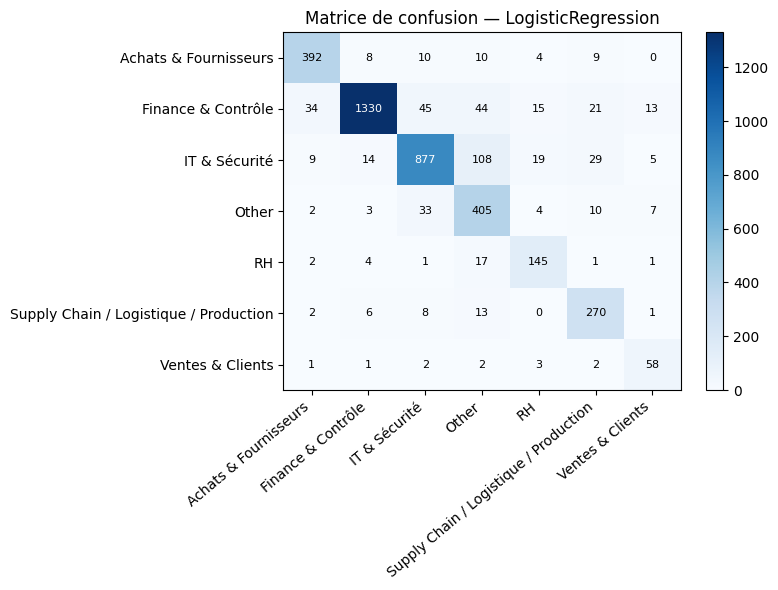

In [20]:
results = []

if RUN_LOGREG:
    def make_logreg():
        return LogisticRegression(C=2.0, max_iter=1000, class_weight="balanced",
                                  solver="lbfgs", n_jobs=-1, random_state=RANDOM_STATE)
    with timer("LogReg fit"):
        logreg = make_logreg()
        logreg.fit(X_train_final, y_train, sample_weight=w_train)
    pred_lr = logreg.predict(X_test_final)
    res_lr = evaluate_predictions(y_test, pred_lr, label_encoder, "LogisticRegression")
    results.append(res_lr)


## 13. Modèle 2 — LinearSVC

[LinearSVC fit] 49.36s
LinearSVC  Macro-F1=0.8781  Weighted-F1=0.9061


,precision,recall,f1-score,support
Achats & Fournisseurs,0.919908,0.928406,0.924138,433.00000
Finance & Contrôle,0.971705,0.937417,0.954253,1502.00000
IT & Sécurité,0.916911,0.884072,0.900192,1061.00000
Other,0.744841,0.855603,0.796389,464.00000
RH,0.896970,0.865497,0.880952,171.00000
Supply Chain / Logistique / Production,0.825688,0.900000,0.861244,300.00000
Ventes & Clients,0.848485,0.811594,0.829630,69.00000
accuracy,0.904750,0.904750,0.904750,0.90475
macro avg,0.874930,0.883227,0.878114,4000.00000
weighted avg,0.908976,0.904750,0.906082,4000.00000


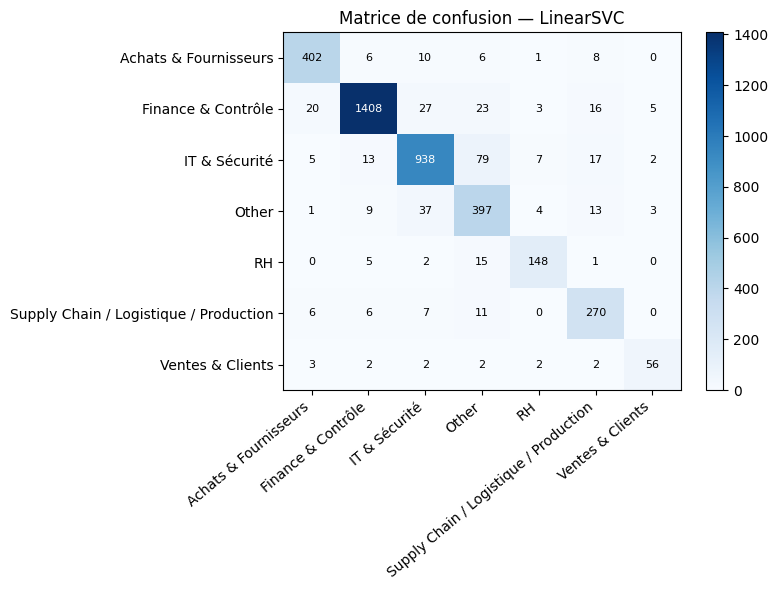

In [21]:
if RUN_LINSVC:
    def make_svc():
        return LinearSVC(C=1.0, class_weight="balanced", random_state=RANDOM_STATE, max_iter=4000)
    with timer("LinearSVC fit"):
        svc = make_svc()
        svc.fit(X_train_final, y_train, sample_weight=w_train)
    pred_svc = svc.predict(X_test_final)
    res_svc = evaluate_predictions(y_test, pred_svc, label_encoder, "LinearSVC")
    results.append(res_svc)


## 14. Modèle 3 — LightGBM

[LightGBM fit] 112.43s
LightGBM  Macro-F1=0.8448  Weighted-F1=0.8840


,precision,recall,f1-score,support
Achats & Fournisseurs,0.913832,0.930716,0.922197,433.00000
Finance & Contrôle,0.960526,0.923435,0.941616,1502.00000
IT & Sécurité,0.879961,0.856739,0.868195,1061.00000
Other,0.716094,0.853448,0.778761,464.00000
RH,0.813333,0.713450,0.760125,171.00000
Supply Chain / Logistique / Production,0.845395,0.856667,0.850993,300.00000
Ventes & Clients,0.760000,0.826087,0.791667,69.00000
accuracy,0.882750,0.882750,0.882750,0.88275
macro avg,0.841306,0.851506,0.844793,4000.00000
weighted avg,0.887361,0.882750,0.884006,4000.00000


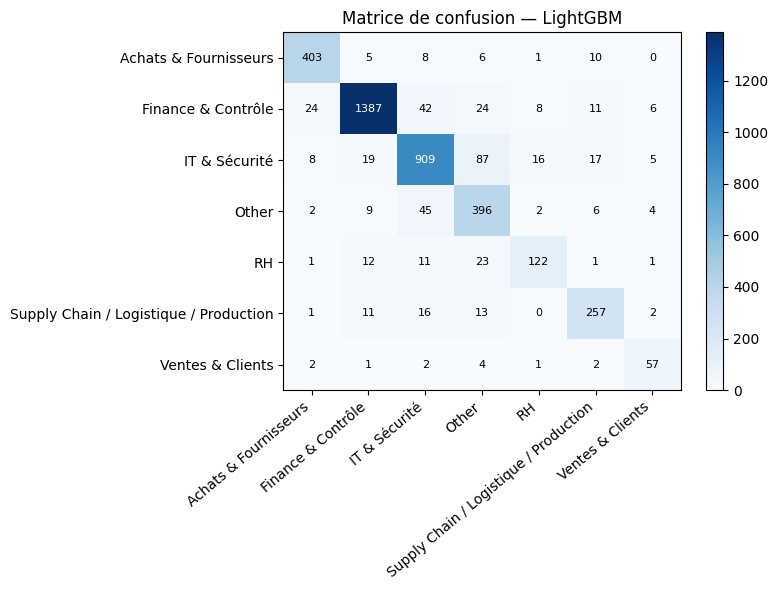

In [22]:
if RUN_LIGHTGBM:
    def make_lgbm():
        return LGBMClassifier(
            objective="multiclass", n_estimators=800,
            learning_rate=0.05, num_leaves=127, min_child_samples=20,
            subsample=0.9, colsample_bytree=0.6, reg_lambda=1.0,
            class_weight="balanced", random_state=RANDOM_STATE,
            n_jobs=-1, verbose=-1)

    X_tr2, X_val2, y_tr2, y_val2, w_tr2, _ = train_test_split(
        X_train_final, y_train, w_train,
        test_size=0.15, random_state=RANDOM_STATE, stratify=y_train)

    with timer("LightGBM fit"):
        lgbm = make_lgbm()
        try:
            from lightgbm import early_stopping, log_evaluation
            lgbm.fit(X_tr2, y_tr2, sample_weight=w_tr2,
                     eval_set=[(X_val2, y_val2)], eval_metric="multi_logloss",
                     callbacks=[early_stopping(30, verbose=False), log_evaluation(0)])
        except ImportError:
            lgbm.fit(X_tr2, y_tr2, sample_weight=w_tr2)

    pred_lgb = lgbm.predict(X_test_final)
    res_lgb = evaluate_predictions(y_test, pred_lgb, label_encoder, "LightGBM")
    results.append(res_lgb)


## 15. CV stratifiée

In [23]:
if RUN_CV:
    cv_results = []
    if RUN_LOGREG:
        print("--- CV LogReg ---")
        cv_results.append(cv_evaluate(make_logreg, X_train_final, y_train,
                                      N_FOLDS, w_train, "LogReg"))
    if RUN_LINSVC:
        print("\n--- CV LinearSVC ---")
        cv_results.append(cv_evaluate(make_svc, X_train_final, y_train,
                                      N_FOLDS, w_train, "LinearSVC"))
    if RUN_LIGHTGBM:
        print("\n--- CV LightGBM ---")
        def make_lgbm_cv():
            return LGBMClassifier(objective="multiclass", n_estimators=400,
                learning_rate=0.05, num_leaves=127, min_child_samples=20,
                subsample=0.9, colsample_bytree=0.6, reg_lambda=1.0,
                class_weight="balanced", random_state=RANDOM_STATE,
                n_jobs=-1, verbose=-1)
        cv_results.append(cv_evaluate(make_lgbm_cv, X_train_final, y_train,
                                      N_FOLDS, w_train, "LightGBM"))
    cv_df = pd.DataFrame(cv_results).sort_values("macro_mean", ascending=False)
    print("\n=== Résultats CV ===")
    print(cv_df.round(4))


--- CV LogReg ---
  fold 1  macro=0.8173  weighted=0.8636
  fold 2  macro=0.8184  weighted=0.8656
  fold 3  macro=0.8216  weighted=0.8675
  fold 4  macro=0.8219  weighted=0.8575
  fold 5  macro=0.8386  weighted=0.8699
[LogReg] macro=0.8235±0.0077 | weighted=0.8648±0.0042

--- CV LinearSVC ---
  fold 1  macro=0.8324  weighted=0.8791
  fold 2  macro=0.8285  weighted=0.8804
  fold 3  macro=0.8477  weighted=0.8857
  fold 4  macro=0.8465  weighted=0.8815
  fold 5  macro=0.8496  weighted=0.8848
[LinearSVC] macro=0.8409±0.0087 | weighted=0.8823±0.0025

--- CV LightGBM ---
  fold 1  macro=0.8289  weighted=0.8785
  fold 2  macro=0.8473  weighted=0.8879
  fold 3  macro=0.8336  weighted=0.8866
  fold 4  macro=0.8496  weighted=0.8865
  fold 5  macro=0.8540  weighted=0.8858
[LightGBM] macro=0.8427±0.0097 | weighted=0.8851±0.0034

=== Résultats CV ===
       model  macro_mean  macro_std  weighted_mean  weighted_std
2   LightGBM      0.8427     0.0097         0.8851        0.0034
1  LinearSVC      0.

## 16. Comparaison hold-out

In [24]:
results_df = pd.DataFrame([
    {"model": r["model"], "macro_f1": r["macro_f1"], "weighted_f1": r["weighted_f1"]}
    for r in results
]).sort_values("macro_f1", ascending=False).reset_index(drop=True)
print(results_df)


                model  macro_f1  weighted_f1
0           LinearSVC  0.878114     0.906082
1            LightGBM  0.844793     0.884006
2  LogisticRegression  0.834890     0.872469


## 17. Feature importance — validation de la pertinence

### Ce qu'on veut vérifier
Les top features doivent maintenant être :
- Des **noms de colonnes métier** (`vendor_id`, `emplid`, `gl_account`...)
- Des **comptages sémantiques** (`sem_financial_amount`, `sem_person_identifier`...)
- Des **keyword counts** (`finance_keyword_count`, `hr_keyword_count`...)

Et PAS des artefacts SQL (`varchar2`, `label`, `identifier`).

=== Top 30 features ===
                    feature  importance
            avg_data_length        2632
                   word__id        1788
                  char__ ps        1590
        log_avg_data_length        1232
                 ratio_text        1230
            max_data_length        1065
             ratio_quantity         989
                field_count         987
                 char__ ps          962
              ratio_numeric         948
                word__setid         935
                  sem_label         882
   non_nullable_field_count         768
                 word__unit         757
           text_field_count         749
                 word__type         736
      finance_keyword_count         734
             word__business         733
                   word__cd         732
                  char__ps          724
         technical_name_len         702
                word__descr         674
             source_ref_len         629
                

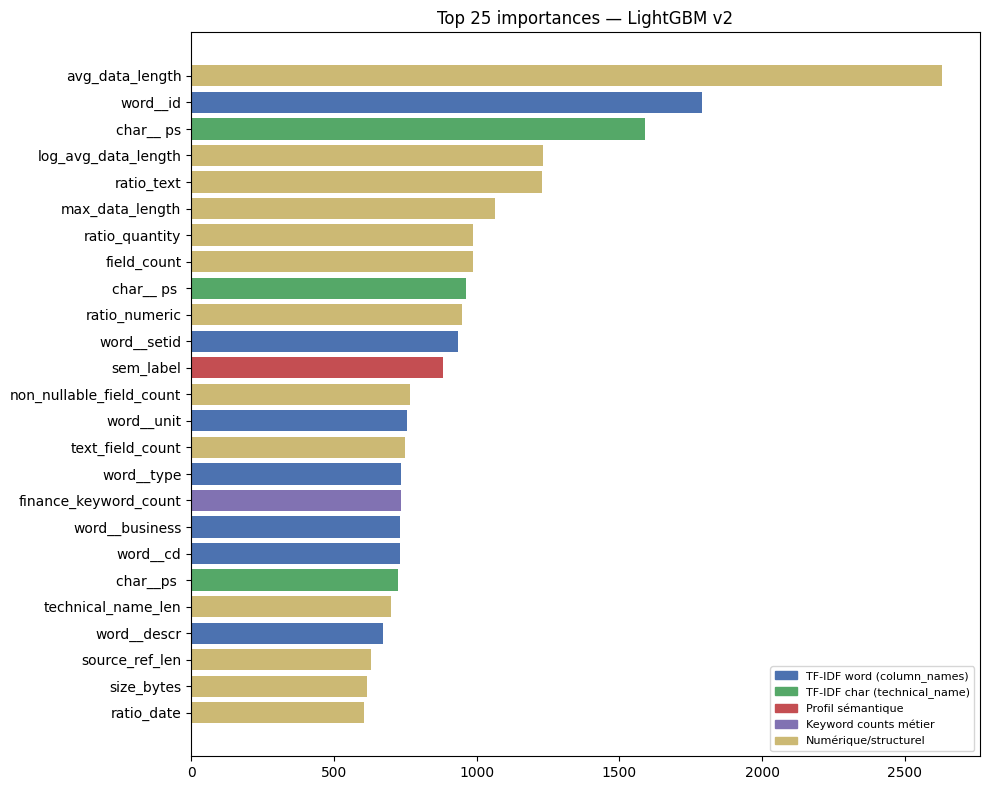


=== Importance totale par bloc ===
block
text_word (column_names)    41886
text_char                   31088
numeric_engineered          12903
semantic_profile            10211
keyword_counts               2495
categorical                     5
Name: importance, dtype: int32

=== Part relative ===
block
text_word (column_names)    42.5 %
text_char                   31.5 %
numeric_engineered          13.1 %
semantic_profile            10.4 %
keyword_counts               2.5 %
categorical                  0.0 %
Name: importance, dtype: str


In [25]:
if RUN_LIGHTGBM:
    imp = pd.DataFrame({
        "feature": all_feat_names,
        "importance": lgbm.feature_importances_,
    }).sort_values("importance", ascending=False)

    print("=== Top 30 features ===")
    print(imp.head(30).to_string(index=False))

    # Vérification : est-ce que varchar2/label/identifier sont encore là ?
    noise_words = ["varchar2", "number", "label", "identifier", "date", "clob"]
    noise_in_top50 = imp.head(50)
    noise_found = noise_in_top50[noise_in_top50["feature"].str.contains("|".join(noise_words), case=False)]
    if len(noise_found) > 0:
        print(f"\n⚠️ {len(noise_found)} features bruit encore dans le top 50:")
        print(noise_found.to_string(index=False))
    else:
        print("\n✅ Aucun artefact SQL dans le top 50 — le nettoyage fonctionne !")

    # Visuel
    top = imp.head(25).iloc[::-1]
    fig, ax = plt.subplots(figsize=(10, 8))
    colors = []
    for f in top["feature"]:
        if f.startswith("word__"):   colors.append("#4C72B0")
        elif f.startswith("char__"): colors.append("#55A868")
        elif f.startswith("sem_"):   colors.append("#C44E52")
        elif "keyword" in f:         colors.append("#8172B2")
        else:                        colors.append("#CCB974")
    ax.barh(top["feature"].astype(str), top["importance"], color=colors)
    ax.set_title("Top 25 importances — LightGBM v2")

    # Légende
    from matplotlib.patches import Patch
    legend = [Patch(color="#4C72B0", label="TF-IDF word (column_names)"),
              Patch(color="#55A868", label="TF-IDF char (technical_name)"),
              Patch(color="#C44E52", label="Profil sémantique"),
              Patch(color="#8172B2", label="Keyword counts métier"),
              Patch(color="#CCB974", label="Numérique/structurel")]
    ax.legend(handles=legend, loc="lower right", fontsize=8)
    plt.tight_layout()
    plt.show()

    # Répartition par bloc
    def feat_block(name):
        if name.startswith("char__"):  return "text_char"
        if name.startswith("word__"):  return "text_word (column_names)"
        if name.startswith("sem_") or name.startswith("ratio_"): return "semantic_profile"
        if "keyword" in name:          return "keyword_counts"
        if name in cat_feat_names:     return "categorical"
        return "numeric_engineered"
    imp["block"] = imp["feature"].map(feat_block)
    print("\n=== Importance totale par bloc ===")
    block_imp = imp.groupby("block")["importance"].sum().sort_values(ascending=False)
    print(block_imp)
    print(f"\n=== Part relative ===")
    print((block_imp / block_imp.sum() * 100).round(1).astype(str) + " %")


## 18. Analyse d'erreurs

In [26]:
best = max(results, key=lambda r: r["macro_f1"])
print("Meilleur modèle :", best["model"])

if best["model"] == "LogisticRegression": best_pred = pred_lr
elif best["model"] == "LinearSVC":        best_pred = pred_svc
else:                                     best_pred = pred_lgb

err_df = X_test.reset_index(drop=True).copy()
err_df["y_true"] = label_encoder.inverse_transform(y_test)
err_df["y_pred"] = label_encoder.inverse_transform(best_pred)
err_df["is_error"] = (err_df["y_true"] != err_df["y_pred"]).astype(int)

errors = err_df[err_df["is_error"]==1]
print(f"\nErreurs : {len(errors)} / {len(err_df)} ({100*len(errors)/len(err_df):.2f}%)")

conf = errors.groupby(["y_true","y_pred"]).size().reset_index(name="n").sort_values("n", ascending=False)
print("\n=== Top confusions ===")
print(conf.head(15))

cols_show = ["technical_name","source_ref","column_names_text","y_true","y_pred"]
print("\n=== Exemples d'erreurs ===")
print(errors[cols_show].head(20).to_string())


Meilleur modèle : LinearSVC

Erreurs : 381 / 4000 (9.53%)

=== Top confusions ===
                                    y_true  \
13                           IT & Sécurité   
19                                   Other   
6                       Finance & Contrôle   
7                       Finance & Contrôle   
5                       Finance & Contrôle   
15                           IT & Sécurité   
9                       Finance & Contrôle   
25                                      RH   
21                                   Other   
12                           IT & Sécurité   
30  Supply Chain / Logistique / Production   
1                    Achats & Fournisseurs   
18                                   Other   
4                    Achats & Fournisseurs   
29  Supply Chain / Logistique / Production   

                                    y_pred   n  
13                                   Other  79  
19                           IT & Sécurité  37  
6                            IT & 

## 19. Sauvegarde

In [27]:
OUTPUT_DIR = Path("artifacts_business_domain")
OUTPUT_DIR.mkdir(exist_ok=True)

artifacts = {
    "label_encoder": label_encoder,
    "char_vectorizer": char_vec,
    "word_vectorizer": word_vec,
    "one_hot_encoder": ohe,
    "num_scaler": num_scaler,
    "config": {
        "TARGET": TARGET, "DROP_COLS": DROP_COLS,
        "DROPPED_TEXT_COLS": DROPPED_TEXT_COLS,
        "TEXT_COLS_CHAR": TEXT_COLS_CHAR, "TEXT_COLS_WORD": TEXT_COLS_WORD,
        "NUM_COLS": NUM_COLS, "CAT_COLS": CAT_COLS,
        "SQL_STOPWORDS": SQL_STOPWORDS,
        "KNOWN_SEMANTIC_LABELS": KNOWN_SEMANTIC_LABELS,
    },
    "feature_names": all_feat_names,
    "numeric_feature_names": num_feat_names,
    "domain_keywords": DOMAIN_KEYWORDS,
    "ps_module_prefixes": PS_MODULE_PREFIXES,
}
if RUN_LOGREG:   artifacts["logreg_model"]   = logreg
if RUN_LINSVC:   artifacts["linsvc_model"]   = svc
if RUN_LIGHTGBM: artifacts["lightgbm_model"] = lgbm

joblib.dump(artifacts, OUTPUT_DIR / "business_domain_pipeline_v2.joblib", compress=3)
results_df.to_csv(OUTPUT_DIR / "model_comparison_holdout.csv", index=False)
if RUN_CV:
    pd.DataFrame(cv_results).to_csv(OUTPUT_DIR / "model_comparison_cv.csv", index=False)
print("Artefacts sauvegardés dans :", OUTPUT_DIR.resolve())


Artefacts sauvegardés dans : C:\Users\Salem\Downloads\artifacts_business_domain


## 20. Fonction d'inférence

In [28]:
def predict_business_domain(df_new, artifacts, model_key="lightgbm_model"):
    cfg = artifacts["config"]
    le  = artifacts["label_encoder"]

    # Drop fuites
    present_drop = [c for c in cfg["DROP_COLS"] + cfg["DROPPED_TEXT_COLS"] if c in df_new.columns]

    # Semantic features AVANT drop
    sem = build_semantic_features(df_new)
    df_new = df_new.drop(columns=present_drop)
    df_p = prepare_dataframe(df_new)

    # TF-IDF
    char_txt = df_p[cfg["TEXT_COLS_CHAR"]].fillna("").astype(str).agg(" ".join, axis=1)
    word_txt = df_p[cfg["TEXT_COLS_WORD"]].fillna("").astype(str).agg(" ".join, axis=1)
    X_char = artifacts["char_vectorizer"].transform(char_txt)
    X_word = artifacts["word_vectorizer"].transform(word_txt)

    # Engineered + semantic + numeric
    eng = build_engineered_features(df_p)
    num_df = pd.concat([
        df_p[cfg["NUM_COLS"]].astype(np.float32).reset_index(drop=True),
        eng.reset_index(drop=True),
        sem.reset_index(drop=True),
    ], axis=1)
    X_num = csr_matrix(artifacts["num_scaler"].transform(num_df.values.astype(np.float32)))

    # Cat
    X_cat = artifacts["one_hot_encoder"].transform(df_p[cfg["CAT_COLS"]].astype(str))

    X_all = hstack([X_char, X_word, X_num, X_cat]).tocsr()
    model = artifacts[model_key]
    return le.inverse_transform(model.predict(X_all))

print("Fonction predict_business_domain définie.")
print("Usage:")
print("  arts = joblib.load('artifacts_business_domain/business_domain_pipeline_v2.joblib')")
print("  preds = predict_business_domain(df_new, arts, 'lightgbm_model')")


Fonction predict_business_domain définie.
Usage:
  arts = joblib.load('artifacts_business_domain/business_domain_pipeline_v2.joblib')
  preds = predict_business_domain(df_new, arts, 'lightgbm_model')


## Récapitulatif v1 → v2

| Aspect | v1 | v2 |
|---|---|---|
| TF-IDF word | 5 colonnes (type_sig, semantics, samples...) | **1 colonne** : `column_names_text` seul |
| Top features LightGBM | `varchar2`, `label`, `identifier` (bruit SQL) | Noms de colonnes métier + profil sémantique |
| `column_value_semantics_text` | TF-IDF (bruit dominant) | **36 features numériques structurées** |
| `column_sample_values_text` | TF-IDF (99.9% vide) | **Supprimé** |
| `column_observed_pattern_text` | TF-IDF (99.9% vide) | **Supprimé** |
| `column_type_signature_text` | TF-IDF (70% varchar2/number) | **Supprimé** |
| Interprétabilité | Opaque (artefacts SQL) | Transparente (vocabulaire métier) |
